# TCREmp 10x dcode Analysis

This notebook reproduces the core 10x dcode workflow with the new CITE-seq infrastructure:
- load donor-level paired VDJ plus binarized CITE-seq matrix into `SingleCellSample`;
- sanity-check binder definitions against VDJdb records with 10x references;
- derive donor1 pseudo-labels from positive binder channels;
- run paired TCREmp embedding and report DBSCAN purity/consistency diagnostics.

In [1]:
# Set deterministic seed and print environment versions used in this analysis.
from __future__ import annotations

import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import sklearn
import umap

from mir.common.single_cell import (
    load_10x_vdj_v1_citeseq_sample,
    validate_citeseq_binders_against_vdjdb_10x,
)
from mir.embedding.tcremp import PairedTCREmp
from mir.utils.embedding_diagnostics import (
    analyze_embedding_dbscan,
    classification_scores_by_label,
    majority_vote_cluster_predictions,
)
from mir.utils.notebook_assets import (
    ensure_airr_benchmark,
    find_airr_benchmark_dcode_10x_vdj_v1_donor,
    find_airr_benchmark_dcode_10x_vdj_v1_donor_matrix,
    find_airr_benchmark_vdjdb_full,
    find_repo_root,
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print(f'Python: {__import__("sys").version.split()[0]}')
print(f'numpy: {np.__version__}')
print(f'polars: {pl.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'umap-learn: {umap.__version__}')

/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.12.12
numpy: 2.4.4
polars: 1.39.3
scikit-learn: 1.8.0
umap-learn: 0.5.12


In [2]:
# Load AIRR benchmark assets and build SingleCellSample objects for all 10x_vdj_v1 donors.
repo_root = find_repo_root(Path.cwd())
dataset_root = ensure_airr_benchmark(repo_root=repo_root, allow_patterns=['dcode/*', 'vdjdb/**'])
vdjdb_full = find_airr_benchmark_vdjdb_full(dataset_root)

donor_ids = ['donor1', 'donor2', 'donor3', 'donor4']
samples = {}
donor_paths = {}

for donor_id in donor_ids:
    all_contig, consensus = find_airr_benchmark_dcode_10x_vdj_v1_donor(dataset_root, donor_id)
    matrix = find_airr_benchmark_dcode_10x_vdj_v1_donor_matrix(dataset_root, donor_id)
    donor_paths[donor_id] = {'all_contig': all_contig, 'consensus': consensus, 'matrix': matrix}
    t0 = time.perf_counter()
    sample = load_10x_vdj_v1_citeseq_sample(
        consensus_annotations_path=consensus,
        all_contig_annotations_path=all_contig,
        binarized_matrix_path=matrix,
        sample_id=donor_id,
    )
    dt = time.perf_counter() - t0
    samples[donor_id] = sample
    print(
        f'{donor_id}: cells={sample.paired_repertoire.loaded_cell_count:,} '
        f'pairs={sample.paired_repertoire.paired_locus_repertoires["TRA_TRB"].clonotype_count:,} '
        f'matrix_rows={sample.cite_seq_matrix.height:,} binder_cols={sample.cite_seq_binder_columns.height:,} '
        f'time={dt:.2f}s'
    )

Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 1907.89it/s]


donor1: cells=47,271 pairs=48,890 matrix_rows=46,526 binder_cols=78 time=1.12s
donor2: cells=79,704 pairs=72,266 matrix_rows=77,854 binder_cols=78 time=1.57s
donor3: cells=38,095 pairs=39,518 matrix_rows=37,824 binder_cols=78 time=1.30s
donor4: cells=27,640 pairs=29,147 matrix_rows=27,308 binder_cols=78 time=0.94s


In [3]:
# Validate donor binder definitions against VDJdb records annotated with 10x references.
sanity_rows = []
for donor_id, sample in samples.items():
    missing = validate_citeseq_binders_against_vdjdb_10x(sample.cite_seq_binder_columns, vdjdb_full)
    sanity_rows.append({
        'donor_id': donor_id,
        'binder_columns': sample.cite_seq_binder_columns.height,
        'missing_targets_vs_vdjdb_10x': missing.height,
    })
    if missing.height > 0:
        print(f'\n{donor_id} residual unmatched targets:')
        print(missing)

sanity_df = pl.DataFrame(sanity_rows).sort('donor_id')
print(sanity_df)


donor1 residual unmatched targets:
shape: (2, 5)
┌─────────────────────────────────┬───────┬─────────────────┬──────────────┬─────────────────┐
│ column                          ┆ hla   ┆ antigen.epitope ┆ antigen.gene ┆ antigen.species │
│ ---                             ┆ ---   ┆ ---             ┆ ---          ┆ ---             │
│ str                             ┆ str   ┆ str             ┆ str          ┆ str             │
╞═════════════════════════════════╪═══════╪═════════════════╪══════════════╪═════════════════╡
│ A0201_CLGGLLTMV_LMP-2A_EBV      ┆ A0201 ┆ CLGGLLTMV       ┆ LMP-2A       ┆ EBV             │
│ A0201_LLMGTLGIVC_HPV-16E7_82-9… ┆ A0201 ┆ LLMGTLGIVC      ┆ HPV-16E7     ┆ 82-91           │
└─────────────────────────────────┴───────┴─────────────────┴──────────────┴─────────────────┘

donor2 residual unmatched targets:
shape: (2, 5)
┌─────────────────────────────────┬───────┬─────────────────┬──────────────┬─────────────────┐
│ column                          ┆ hla   ┆ a

In [4]:
# Build donor1 paired clonotype labels from positive CITE-seq binder channels and prepare embeddings.
def donor1_binder_labels(sample):
    binder_cols = sample.cite_seq_binder_columns.filter(pl.col('is_binder') == '1').get_column('column').to_list()
    if not binder_cols:
        raise ValueError('No binder columns found in donor CITE-seq matrix')

    long = (
        sample.cite_seq_matrix
        .select(['barcode', *binder_cols])
        .unpivot(index='barcode', variable_name='column', value_name='value')
        .filter(pl.col('value') == 1)
    )
    if long.height == 0:
        raise ValueError('No positive binder events found')

    info = sample.cite_seq_binder_columns.select(['column', 'hla', 'antigen.epitope'])
    labels = (
        long.join(info, on='column', how='left')
        .group_by('barcode', 'antigen.epitope')
        .len()
        .sort(['barcode', 'len', 'antigen.epitope'], descending=[False, True, False])
        .group_by('barcode')
        .first()
        .select(['barcode', pl.col('antigen.epitope').alias('epitope_label')])
    )
    return labels


donor1 = samples['donor1']
labels_df = donor1_binder_labels(donor1)

# Link CITE barcodes to clonotype IDs using all-contig annotations.
all_contig_df = pl.read_csv(donor_paths['donor1']['all_contig']).select(['barcode', 'raw_clonotype_id']).drop_nulls()
clonotype_labels = (
    all_contig_df.join(labels_df, on='barcode', how='inner')
    .group_by('raw_clonotype_id', 'epitope_label')
    .len()
    .sort(['raw_clonotype_id', 'len', 'epitope_label'], descending=[False, True, False])
    .group_by('raw_clonotype_id')
    .first()
    .rename({'raw_clonotype_id': 'clonotype_id'})
    .select(['clonotype_id', 'epitope_label'])
)
clonotype_label_map = {
    row['clonotype_id']: row['epitope_label']
    for row in clonotype_labels.iter_rows(named=True)
}

pairs = []
rows = []
for pair in donor1.paired_repertoire.paired_locus_repertoires['TRA_TRB'].paired_clonotypes:
    clonotype_id = pair.pair_id.split('_', 1)[0]
    epitope = clonotype_label_map.get(clonotype_id)
    if epitope is None:
        continue
    pairs.append(pair)
    rows.append({'clonotype_id': clonotype_id, 'epitope_label': epitope})

label_table = pl.DataFrame(rows)
label_counts = label_table.group_by('epitope_label').len().sort('len', descending=True)

print(f'Paired clonotypes with donor1 CITE labels: {len(pairs):,}')
print(label_counts.head(10))

Paired clonotypes with donor1 CITE labels: 22,035
shape: (10, 2)
┌───────────────┬───────┐
│ epitope_label ┆ len   │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ KLGGALQAK     ┆ 10598 │
│ AVFDRKSDAK    ┆ 3799  │
│ IVTDFSVIK     ┆ 3450  │
│ GILGFVFTL     ┆ 2858  │
│ RAKFKQLL      ┆ 599   │
│ ELAGIGILTV    ┆ 276   │
│ LLDFVRFMGV    ┆ 158   │
│ RLRAEAQVK     ┆ 105   │
│ GLCTLVAML     ┆ 63    │
│ FLYALALLL     ┆ 23    │
└───────────────┴───────┘


In [5]:
# Embed donor1 balanced clonotypes in TRA, TRB, and paired spaces and compute clustering/classification diagnostics.
MAX_PER_EPITOPE = 250
OTHER_LABEL = 'other'
TOP_LABELS = label_table.group_by('epitope_label').len().sort('len', descending=True).head(10).get_column('epitope_label').to_list()

balanced_parts = []
for label in TOP_LABELS:
    part = label_table.filter(pl.col('epitope_label') == label)
    balanced_parts.append(part.sample(n=min(MAX_PER_EPITOPE, part.height), seed=SEED, shuffle=True))

other = label_table.filter(~pl.col('epitope_label').is_in(TOP_LABELS))
if other.height > 0:
    balanced_parts.append(other.sample(n=min(500, other.height), seed=SEED, shuffle=True).with_columns(pl.lit(OTHER_LABEL).alias('epitope_label')))

balanced = pl.concat(balanced_parts, how='vertical')
pair_index = {pair.pair_id.split('_', 1)[0]: pair for pair in pairs}
balanced_pairs = [pair_index[c] for c in balanced.get_column('clonotype_id').to_list()]
balanced_labels = balanced.get_column('epitope_label').to_numpy()

model = PairedTCREmp.from_defaults(species='human', locus_pair='TRA_TRB', n_prototypes=500, junction_method='fixed_gap')

tra_only = [pair.clonotype1 if pair.clonotype1.locus == 'TRA' else pair.clonotype2 for pair in balanced_pairs]
trb_only = [pair.clonotype1 if pair.clonotype1.locus == 'TRB' else pair.clonotype2 for pair in balanced_pairs]

t0 = time.perf_counter()
X_pair = model.embed(balanced_pairs)
t_pair = time.perf_counter() - t0

t0 = time.perf_counter()
X_tra = model.chain1_model.embed(tra_only)
t_tra = time.perf_counter() - t0

t0 = time.perf_counter()
X_trb = model.chain2_model.embed(trb_only)
t_trb = time.perf_counter() - t0

mode_embeddings = {
    'TRA': X_tra,
    'TRB': X_trb,
    'TRA_TRB': X_pair,
}

mode_results = {}
mode_rows = []
score_rows = []

for mode, X_mode in mode_embeddings.items():
    analysis = analyze_embedding_dbscan(
        X_mode,
        balanced_labels,
        seed=SEED,
        min_samples=2,
        k_neighbors=4,
        pca_variance_threshold=0.90,
    )
    predicted = majority_vote_cluster_predictions(balanced_labels, analysis['clusters'])
    scores = classification_scores_by_label(balanced_labels, predicted)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        X_umap = umap.UMAP(
            n_components=2,
            n_neighbors=30,
            min_dist=0.10,
            metric='euclidean',
            random_state=SEED,
        ).fit_transform(analysis['X_pca'])

    mode_results[mode] = {
        'X': X_mode,
        'analysis': analysis,
        'predicted': predicted,
        'scores': scores,
        'X_umap': X_umap,
    }

    mode_rows.append(
        {
            'mode': mode,
            'n_records': int(len(balanced_labels)),
            'embed_time_s': float({'TRA': t_tra, 'TRB': t_trb, 'TRA_TRB': t_pair}[mode]),
            'pcs_90pct': int(analysis['n_comp']),
            'eps': float(analysis['eps']),
            'clusters': int(analysis['n_clusters']),
            'retention': float(analysis['retention']),
            'purity': float(analysis['purity']),
            'consistency_70': float(analysis['consistency']),
            'macro_f1': float(scores['macro_f1']),
            'weighted_f1': float(scores['weighted_f1']),
            'accuracy': float(scores['accuracy']),
        }
    )

    for rec in scores['per_label']:
        score_rows.append(
            {
                'mode': mode,
                'epitope': rec['label'],
                'precision': float(rec['precision']),
                'recall': float(rec['recall']),
                'f1': float(rec['f1']),
                'support': int(rec['support']),
            }
        )

mode_summary = pl.DataFrame(mode_rows).sort('mode')
epitope_scores = pl.DataFrame(score_rows).sort(['mode', 'f1'], descending=[False, True])

print(f'Balanced donor1 records: {balanced.height:,}')
print(f'Embedding runtime TRA: {t_tra:.3f}s  TRB: {t_trb:.3f}s  TRA_TRB: {t_pair:.3f}s')
print(mode_summary)
print('\nTop epitope classification rows by F1 per mode:')
print(epitope_scores.group_by('mode').head(8).sort(['mode', 'f1'], descending=[False, True]))

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Balanced donor1 records: 1,955
Embedding runtime TRA: 0.027s  TRB: 0.028s  TRA_TRB: 0.058s
shape: (3, 12)
┌─────────┬───────────┬────────────┬───────────┬───┬────────────┬──────────┬────────────┬──────────┐
│ mode    ┆ n_records ┆ embed_time ┆ pcs_90pct ┆ … ┆ consistenc ┆ macro_f1 ┆ weighted_f ┆ accuracy │
│ ---     ┆ ---       ┆ _s         ┆ ---       ┆   ┆ y_70       ┆ ---      ┆ 1          ┆ ---      │
│ str     ┆ i64       ┆ ---        ┆ i64       ┆   ┆ ---        ┆ f64      ┆ ---        ┆ f64      │
│         ┆           ┆ f64        ┆           ┆   ┆ f64        ┆          ┆ f64        ┆          │
╞═════════╪═══════════╪════════════╪═══════════╪═══╪════════════╪══════════╪════════════╪══════════╡
│ TRA     ┆ 1955      ┆ 0.027174   ┆ 23        ┆ … ┆ 0.905983   ┆ 0.731314 ┆ 0.792056   ┆ 0.702302 │
│ TRA_TRB ┆ 1955      ┆ 0.058448   ┆ 39        ┆ … ┆ 0.972112   ┆ 0.724149 ┆ 0.776141   ┆ 0.666496 │
│ TRB     ┆ 1955      ┆ 0.027725   ┆ 21        ┆ … ┆ 0.935484   ┆ 0.732317 ┆ 0.792513 

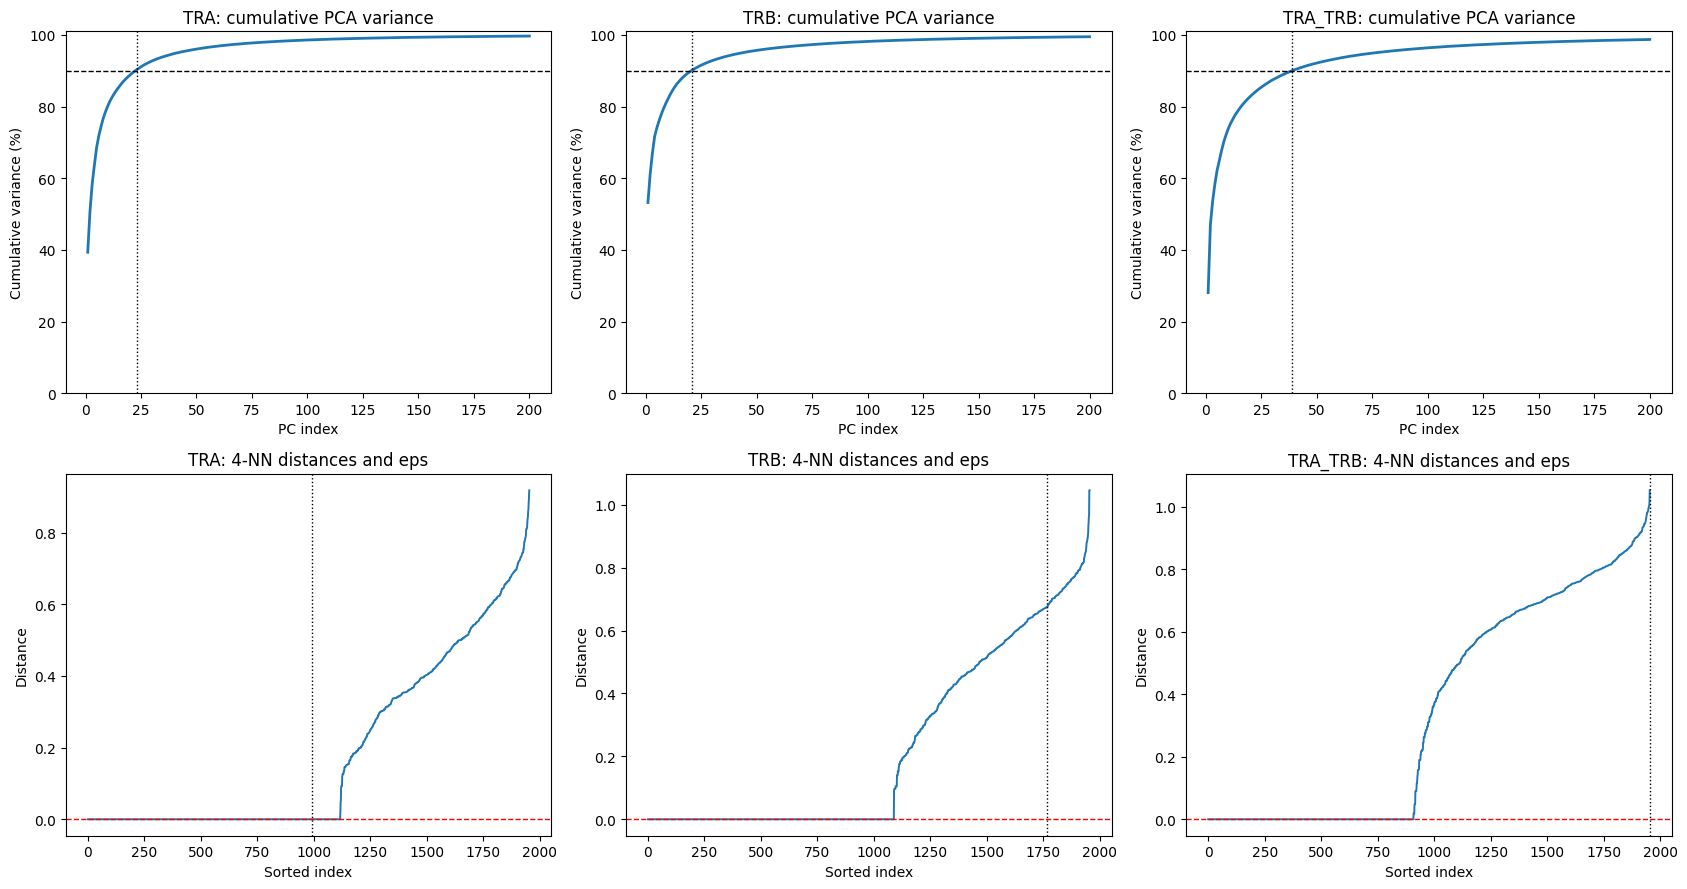

In [6]:
# Plot cumulative PCA variance and k-nearest-neighbor distance curves for eps selection.
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for col, mode in enumerate(['TRA', 'TRB', 'TRA_TRB']):
    analysis = mode_results[mode]['analysis']

    max_show = min(200, len(analysis['cum']))
    ax = axes[0, col]
    ax.plot(np.arange(1, max_show + 1), analysis['cum'][:max_show] * 100, lw=2)
    ax.axhline(90, color='black', ls='--', lw=1)
    ax.axvline(analysis['n_comp'], color='black', ls=':', lw=1)
    ax.set_title(f'{mode}: cumulative PCA variance')
    ax.set_xlabel('PC index')
    ax.set_ylabel('Cumulative variance (%)')
    ax.set_ylim(0, 101)

    kth = analysis['kth']
    ax = axes[1, col]
    ax.plot(kth, lw=1.4)
    if analysis['knee_idx'] is not None:
        ax.axvline(int(analysis['knee_idx']), color='black', ls=':', lw=1)
    ax.axhline(float(analysis['eps']), color='red', ls='--', lw=1)
    ax.set_title(f'{mode}: 4-NN distances and eps')
    ax.set_xlabel('Sorted index')
    ax.set_ylabel('Distance')

plt.tight_layout()
plt.show()

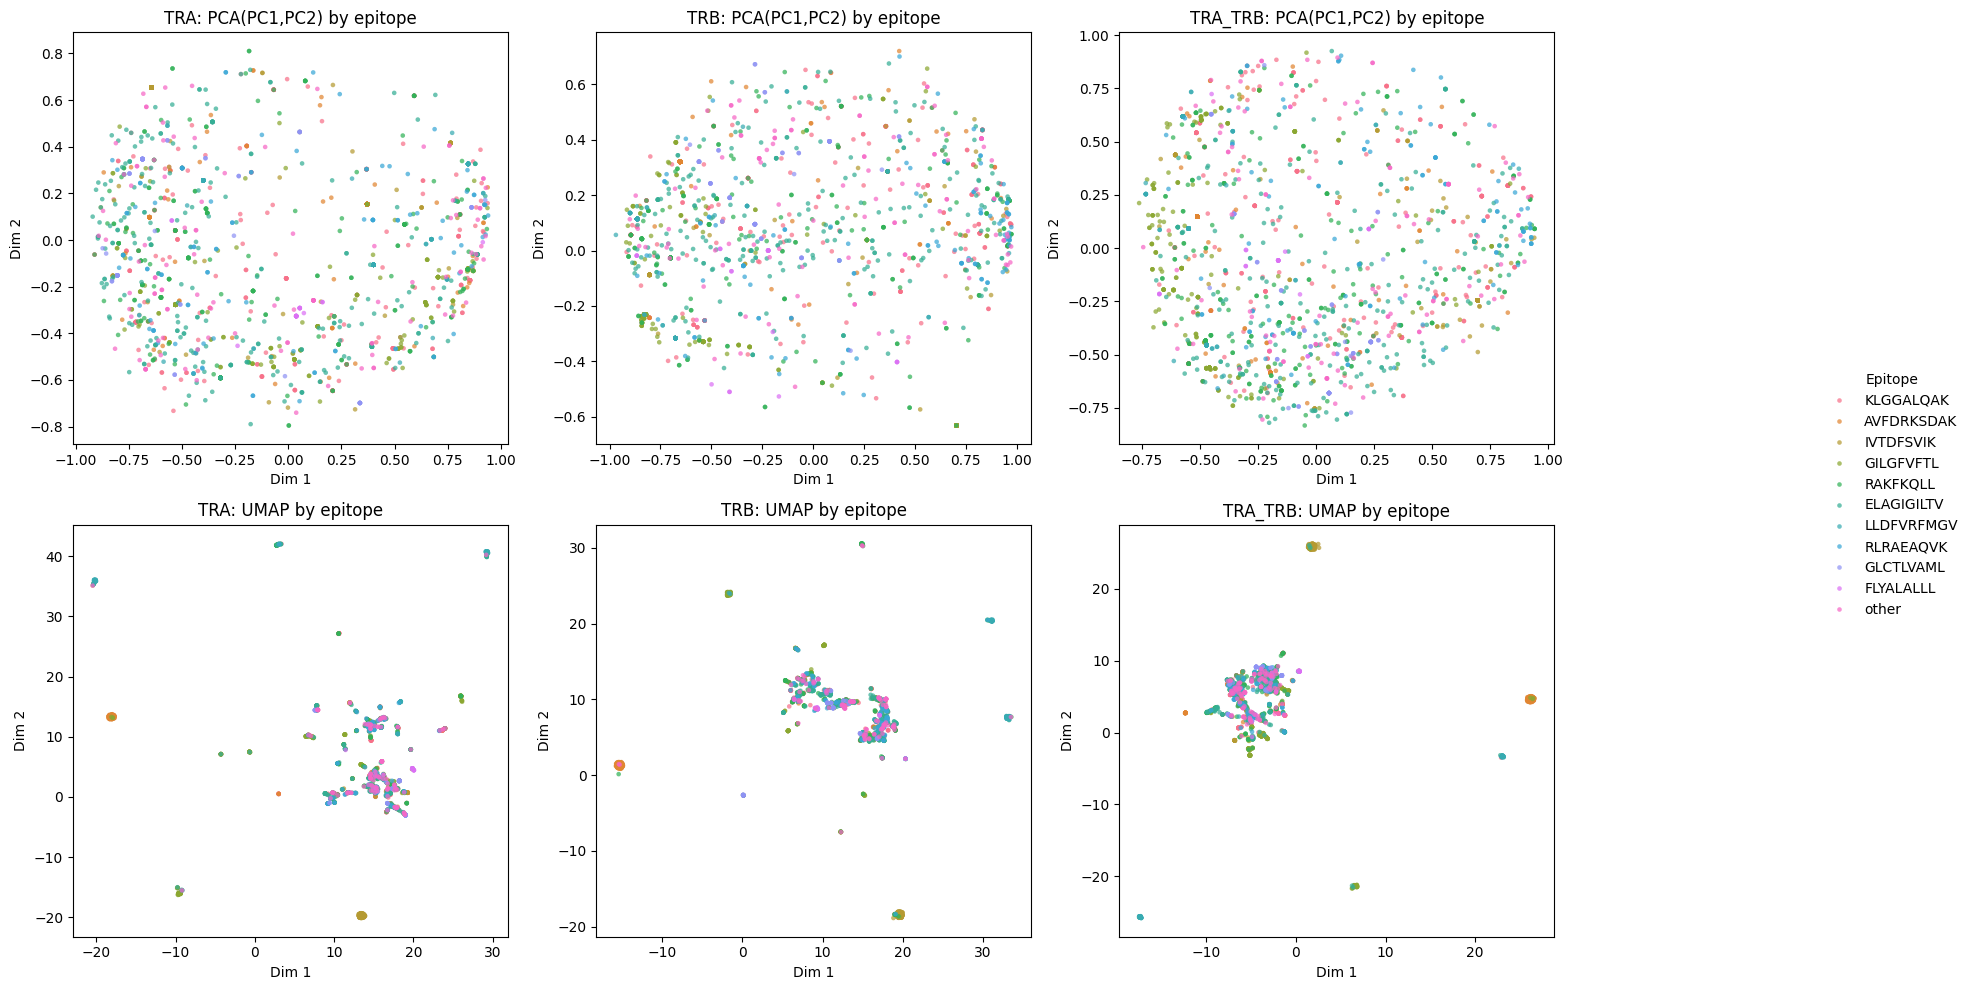

In [7]:
# Plot PCA and UMAP projections colored by donor1 CITE-seq epitope labels.
def _plot_projection(ax, coords, labels, title):
    plot_df = pl.DataFrame({'x': coords[:, 0], 'y': coords[:, 1], 'label': labels})
    top_labels = (
        plot_df.group_by('label').len().sort('len', descending=True).head(12).get_column('label').to_list()
    )
    display = plot_df.with_columns(
        pl.when(pl.col('label').is_in(top_labels)).then(pl.col('label')).otherwise(pl.lit('other')).alias('label_disp')
    )
    sns.scatterplot(
        data=display.to_pandas(),
        x='x',
        y='y',
        hue='label_disp',
        s=11,
        alpha=0.72,
        linewidth=0,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, mode in enumerate(['TRA', 'TRB', 'TRA_TRB']):
    pca_coords = mode_results[mode]['analysis']['X_pca'][:, :2]
    umap_coords = mode_results[mode]['X_umap']

    _plot_projection(axes[0, col], pca_coords, balanced_labels, f'{mode}: PCA(PC1,PC2) by epitope')
    _plot_projection(axes[1, col], umap_coords, balanced_labels, f'{mode}: UMAP by epitope')

handles, labels = axes[1, 2].get_legend_handles_labels()
for r in range(2):
    for c in range(3):
        if axes[r, c].legend_ is not None:
            axes[r, c].legend_.remove()

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, title='Epitope')
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

In [8]:
# Display epitope-level classification score tables by mode.
for mode in ['TRA', 'TRB', 'TRA_TRB']:
    print(f'\n{mode} epitope classification scores (top 15 by support):')
    display_df = (
        epitope_scores
        .filter(pl.col('mode') == mode)
        .sort(['support', 'f1'], descending=[True, True])
        .head(15)
    )
    print(display_df)

print('\nGlobal mode summary with clustering and classification metrics:')
print(mode_summary.sort('weighted_f1', descending=True))


TRA epitope classification scores (top 15 by support):
shape: (11, 6)
┌──────┬────────────┬───────────┬──────────┬──────────┬─────────┐
│ mode ┆ epitope    ┆ precision ┆ recall   ┆ f1       ┆ support │
│ ---  ┆ ---        ┆ ---       ┆ ---      ┆ ---      ┆ ---     │
│ str  ┆ str        ┆ f64       ┆ f64      ┆ f64      ┆ i64     │
╞══════╪════════════╪═══════════╪══════════╪══════════╪═════════╡
│ TRA  ┆ IVTDFSVIK  ┆ 0.995536  ┆ 0.892    ┆ 0.940928 ┆ 250     │
│ TRA  ┆ AVFDRKSDAK ┆ 0.967593  ┆ 0.836    ┆ 0.896996 ┆ 250     │
│ TRA  ┆ GILGFVFTL  ┆ 0.956522  ┆ 0.792    ┆ 0.866521 ┆ 250     │
│ TRA  ┆ RAKFKQLL   ┆ 0.897297  ┆ 0.664    ┆ 0.763218 ┆ 250     │
│ TRA  ┆ KLGGALQAK  ┆ 0.868571  ┆ 0.608    ┆ 0.715294 ┆ 250     │
│ …    ┆ …          ┆ …         ┆ …        ┆ …        ┆ …       │
│ TRA  ┆ LLDFVRFMGV ┆ 0.993464  ┆ 0.962025 ┆ 0.977492 ┆ 158     │
│ TRA  ┆ other      ┆ 1.0       ┆ 0.367925 ┆ 0.537931 ┆ 106     │
│ TRA  ┆ RLRAEAQVK  ┆ 0.87931   ┆ 0.485714 ┆ 0.625767 ┆ 105     │
│ TRA